In [17]:
import re
from pathlib import Path
import pandas as pd

EMO_DIR = Path("../Emotions")

def source_of(name):
    if re.match(r"^\d+-\d+-", name):             return "RAVDESS"
    if re.match(r"^\d{4}_", name):               return "CREMA-D"
    if re.match(r"^(OAF|YAF|OA)_", name):        return "TESS"
    if re.match(r"^[a-z]{1,2}\d+\.wav$", name):  return "SAVEE"
    return "other"

rows = []
for emo_path in sorted(p for p in EMO_DIR.iterdir() if p.is_dir()):
    for wav in sorted(emo_path.glob("*.wav")):
        rows.append({"filename": wav.name, "emotion": emo_path.name,
                     "source": source_of(wav.name), "path": str(wav)})
df = pd.DataFrame(rows)

# Keep only CREMA-D + RAVDESS, drop the Surprised emotion (folder spelled 'Suprised')
df = df[df["source"].isin(["CREMA-D", "RAVDESS"])]
df = df[df["emotion"] != "Suprised"].reset_index(drop=True)
print(f"{len(df)} clips, {df['emotion'].nunique()} emotions")
df["emotion"].value_counts()

9326 clips, 6 emotions


emotion
Angry        1647
Fearful      1647
Happy        1647
Sad          1647
Disgusted    1463
Neutral      1275
Name: count, dtype: int64

Sad: 100%|██████████| 1647/1647 [00:02<00:00, 799.39it/s] 


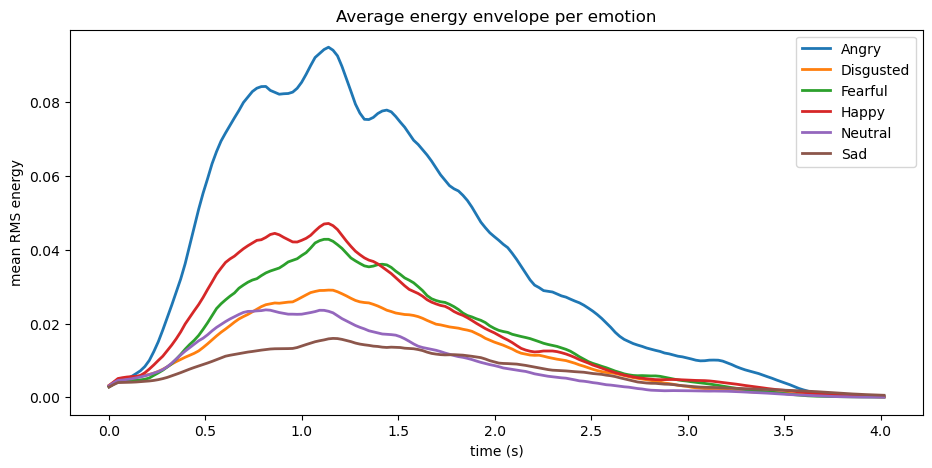

In [18]:
import numpy as np, librosa, matplotlib.pyplot as plt
from tqdm.auto import tqdm

SR, HOP, MAX_FRAMES = 22050, 512, 174     # ~4s window

def rms_envelope(path):
    y, _ = librosa.load(path, sr=SR)
    r = librosa.feature.rms(y=y, hop_length=HOP)[0]          # energy per frame
    return r[:MAX_FRAMES] if len(r) >= MAX_FRAMES else np.pad(r, (0, MAX_FRAMES - len(r)))

# Use a sample per emotion for speed (set N=None to use every clip)
N = None
src = df
sub = src.groupby("emotion", group_keys=False).sample(n=N, random_state=0) if N else src

env = {}
for emo in sorted(sub["emotion"].unique()):
    paths = sub[sub["emotion"] == emo]["path"]
    env[emo] = np.stack([rms_envelope(p) for p in tqdm(paths, desc=emo)]).mean(0)

t = np.arange(MAX_FRAMES) * HOP / SR        # x-axis in seconds
plt.figure(figsize=(11, 5))
for emo, e in env.items():
    plt.plot(t, e, label=emo, lw=2)
plt.xlabel("time (s)"); plt.ylabel("mean RMS energy")
plt.title("Average energy envelope per emotion"); plt.legend(); plt.show()


In [19]:
import librosa
from tqdm.auto import tqdm

# Raw clip duration (header read, no full decode) and drop clips outside 1–5s
df["duration"] = [librosa.get_duration(path=p) for p in tqdm(df["path"], desc="duration")]

before = len(df)
df = df[(df["duration"] >= 1.0) & (df["duration"] <= 5.0)].reset_index(drop=True)
print(f"removed {before - len(df)} clips  ({before} -> {len(df)} remain)")
df["emotion"].value_counts()

duration: 100%|██████████| 9326/9326 [00:01<00:00, 5910.47it/s]

removed 108 clips  (9326 -> 9218 remain)


emotion
Fearful      1643
Angry        1633
Happy        1632
Sad          1577
Disgusted    1462
Neutral      1271
Name: count, dtype: int64

duration: 100%|██████████| 9218/9218 [00:00<00:00, 21758.80it/s]


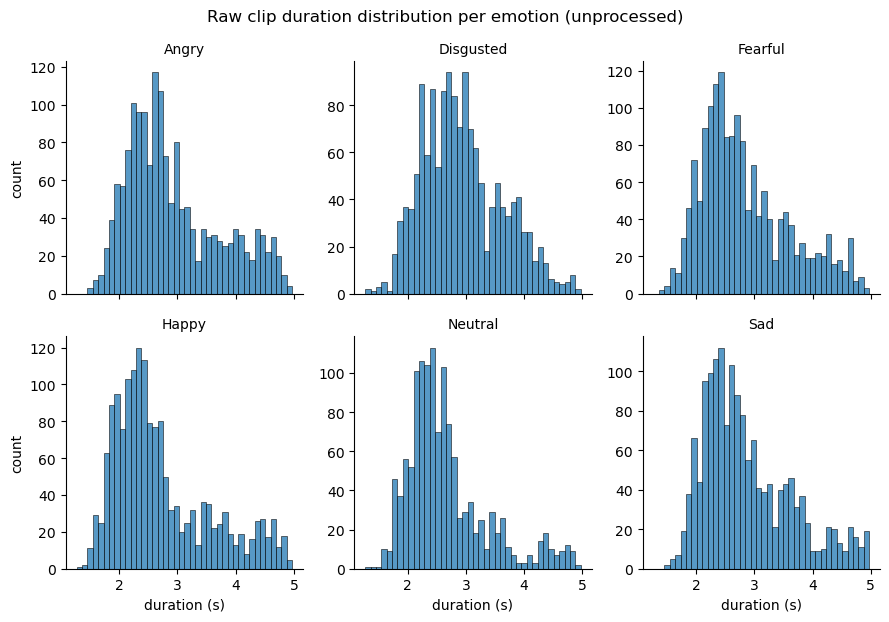

In [20]:
import seaborn as sns


dur_df = df.copy()
dur_df["duration"] = [librosa.get_duration(path=p) for p in tqdm(df["path"], desc="duration")]

g = sns.displot(data=dur_df, x="duration", col="emotion", col_wrap=3,
                bins=40, height=3, facet_kws={"sharey": False})
g.set_axis_labels("duration (s)", "count")
g.set_titles("{col_name}")
g.figure.suptitle("Raw clip duration distribution per emotion (unprocessed)", y=1.03)
plt.show()

## CNN model

14-channel input of shape `(40, MAX_FRAMES, 14)` — extracted **per split** (`dftrain` / `dftest`) so the test set never leaks into training stats.

| ch | feature | shape | role |
|---|---|---|---|
| 0 | MFCC (40) | 2D | timbre / spectral envelope |
| 1 | Δ MFCC (delta) | 2D | how timbre changes (velocity) |
| 2 | ΔΔ MFCC (delta-delta) | 2D | acceleration of timbre |
| 3 | RMS energy | 1D → broadcast | loudness / arousal |
| 4 | pitch (f0, pyin, voiced) | 1D → broadcast | intonation |
| 5 | spectral centroid | 1D → broadcast | brightness |
| 6 | spectral flux | 1D → broadcast | frame-to-frame spectral change (dynamics) |
| 7 | spectral contrast (mean over bands) | 1D → broadcast | peak-to-valley gap (harmonic structure) |
| 8 | **f0 std** | scalar → const plane | pitch variability |
| 9 | **f0 range (5–95 pct)** | scalar → const plane | pitch span |
| 10 | **pitch slope** | scalar → const plane | overall rise/fall (Hz/frame) |
| 11 | **jitter** | scalar → const plane | cycle-to-cycle period perturbation (voice quality) |
| 12 | **shimmer** | scalar → const plane | cycle-to-cycle amplitude perturbation (voice quality) |
| 13 | **HNR** | scalar → const plane | harmonic-to-noise ratio (breathy/creaky) |

**Removed** from the earlier stack: zero-crossing rate and spectral flatness (weak marginal separators).

**New this version**, targeting the Fearful↔Sad and Sad↔Disgusted confusions:
- **Pitch contour** (ch 8–10) captures *how pitch moves over the clip* — Fearful's trembling/rising intonation vs Sad's flat, falling pitch — which a time-averaged f0 misses.
- **Voice quality** (ch 11–13) captures phonation type (creaky/breathy/rough) that distinguishes Disgust/Sad from Neutral.

The per-frame 1D features are tiled across the 40 MFCC rows; the six clip-level scalars are broadcast to constant planes so every channel shares the `(40, MAX_FRAMES)` shape. Spectral contrast is natively 2D `(7 bands, T)` and reduced to its band-mean.

> **Note:** jitter/shimmer/HNR are **librosa proxies** (parselmouth/Praat isn't installed). For publication-grade voice-quality measures, `pip install praat-parselmouth` and swap these in.

In [ ]:
import numpy as np
import librosa
from tqdm.auto import tqdm

SR         = 22050
N_MFCC     = 40
HOP        = 512
MAX_FRAMES = int(np.ceil(5 * SR / HOP))   # 216 frames -> covers the 5s duration cap
AUG_ROUNDS = 1                            # extra augmented copies of the TRAIN set (0 = off)

def _fit2d(m):            # pad/truncate a (rows, T) array along time
    if m.shape[1] < MAX_FRAMES:
        return np.pad(m, ((0, 0), (0, MAX_FRAMES - m.shape[1])))
    return m[:, :MAX_FRAMES]

def _fit1d(a):            # pad/truncate a (T,) array, then broadcast across the MFCC rows
    a = a[:MAX_FRAMES] if len(a) >= MAX_FRAMES else np.pad(a, (0, MAX_FRAMES - len(a)))
    return np.tile(a, (N_MFCC, 1))                      # (N_MFCC, MAX_FRAMES)

def _const(v):            # broadcast a single clip-level scalar to a full (N_MFCC, MAX_FRAMES) plane
    return np.full((N_MFCC, MAX_FRAMES), v, dtype="float32")

def features(path, augment=False):
    y, sr = librosa.load(path, sr=SR)
    if augment:                                          # waveform-level aug (TRAIN only)
        if np.random.rand() < 0.5:
            y = y + 0.01 * np.random.randn(len(y))                                       # additive noise
        if np.random.rand() < 0.5:
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2, 2))  # pitch shift
        if np.random.rand() < 0.5:
            y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.9, 1.1))        # speed change
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP)   # (40, T)
    d1   = librosa.feature.delta(mfcc)                  # delta (velocity)
    d2   = librosa.feature.delta(mfcc, order=2)         # delta-delta (acceleration)
    rms  = librosa.feature.rms(y=y, hop_length=HOP)[0]
    cen  = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP)[0]
    S    = np.abs(librosa.stft(y, hop_length=HOP))
    flux = np.concatenate([[0.0], np.sqrt((np.diff(S, axis=1) ** 2).sum(0))])          # (T,) frame-to-frame change
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP).mean(0)   # (T,) mean peak-valley gap

    # --- pitch via pyin: voiced-only f0 lets us measure the CONTOUR (Fearful tremor vs Sad flatness) ---
    f0, voiced, _ = librosa.pyin(y, fmin=65, fmax=2093, sr=sr, hop_length=HOP)
    f0_frame = np.nan_to_num(f0, nan=0.0)               # per-frame pitch channel
    v = f0[~np.isnan(f0)]                               # voiced f0 values (Hz)
    if len(v) >= 2:
        idx      = np.flatnonzero(~np.isnan(f0)).astype(float)
        f0_std   = float(v.std())                                   # pitch variability
        f0_range = float(np.percentile(v, 95) - np.percentile(v, 5))  # robust pitch span
        slope    = float(np.polyfit(idx, v, 1)[0])                  # overall rise/fall (Hz/frame)
        T        = 1.0 / v                                          # glottal periods (s)
        jitter   = float(np.abs(np.diff(T)).mean() / (T.mean() + 1e-9))   # period perturbation
    else:
        f0_std = f0_range = slope = jitter = 0.0

    # --- voice-quality proxies (no Praat): shimmer from frame amplitude, HNR from harmonic/noise energy ---
    m   = min(len(rms), len(voiced))
    amp = rms[:m][voiced[:m]]                           # amplitude on voiced frames
    shimmer = float(np.abs(np.diff(amp)).mean() / (amp.mean() + 1e-9)) if len(amp) >= 2 else 0.0
    yh, yp = librosa.effects.hpss(y)                    # harmonic vs percussive(noise) components
    hnr = float(10 * np.log10((yh ** 2).sum() / ((yp ** 2).sum() + 1e-9) + 1e-9))

    return np.stack([
        _fit2d(mfcc), _fit2d(d1), _fit2d(d2),                     # 0-2  timbre + velocity + accel
        _fit1d(rms), _fit1d(f0_frame), _fit1d(cen),               # 3-5  loudness, pitch, brightness
        _fit1d(flux), _fit1d(contrast),                           # 6-7  dynamics, harmonic structure
        _const(f0_std), _const(f0_range), _const(slope),          # 8-10 pitch contour
        _const(jitter), _const(shimmer), _const(hnr),             # 11-13 voice quality
    ], axis=-1)                                                    # (40, MAX_FRAMES, 14)

def build_X(frame, desc, augment=False):
    return np.stack([features(p, augment=augment) for p in tqdm(frame["path"], desc=desc)]).astype("float32")

# Extract per split (no leakage — test clips never touched during training)
# Train = clean copy + AUG_ROUNDS augmented copies; the test set is NEVER augmented.
# NOTE: pyin makes this noticeably slower than before — expect a longer extraction.
X_train = build_X(dftrain, "train")
for r in range(AUG_ROUNDS):
    X_train = np.concatenate([X_train, build_X(dftrain, f"train-aug{r+1}", augment=True)])
X_test  = build_X(dftest,  "test")
print("X_train:", X_train.shape, " X_test:", X_test.shape)   # (n*(1+AUG_ROUNDS), 40, 216, 14)
# np.save('Xtr_mypick.npy', X_train); np.save('Xte_mypick.npy', X_test)  # uncomment to cache

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
ytr_int = le.fit_transform(dftrain["emotion"])
yte_int = le.transform(dftest["emotion"])
print("classes:", list(le.classes_))

# Class weights from the ORIGINAL train labels (handles Neutral/Disgusted being under-represented)
cw = compute_class_weight("balanced", classes=np.unique(ytr_int), y=ytr_int)
class_weight = dict(enumerate(cw))
print("class_weight:", {le.classes_[k]: round(v, 3) for k, v in class_weight.items()})

# Repeat labels to match the (1 clean + AUG_ROUNDS) copies concatenated in build_X
ytr = to_categorical(np.tile(ytr_int, 1 + AUG_ROUNDS))
yte = to_categorical(yte_int)

# Per-channel standardization using TRAIN stats only (each feature is on a different scale).
# Write to NEW arrays (X_train_n / X_test_n) so re-running this cell always normalizes the
# raw X_train/X_test — idempotent, never double-normalizes.
axes = (0, 1, 2)                                   # over samples, mfcc rows, time -> one stat per channel
mean = X_train.mean(axis=axes, keepdims=True)
std  = X_train.std(axis=axes, keepdims=True)
X_train_n = (X_train - mean) / (std + 1e-9)
X_test_n  = (X_test  - mean) / (std + 1e-9)
print("X_train_n:", X_train_n.shape, " X_test_n:", X_test_n.shape)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=X_train_n.shape[1:]),           # (40, MAX_FRAMES, 10)
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(ytr.shape[1], activation="softmax"),  # 6 emotions
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train_n, ytr, validation_data=(X_test_n, yte),
    epochs=50, batch_size=32,
    class_weight=class_weight,                         # counter class imbalance
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=4, min_lr=1e-5),  # calm the val swings
    ],
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

pred = model.predict(X_test_n).argmax(1)
true = yte.argmax(1)
print(classification_report(true, pred, target_names=le.classes_))

cm = confusion_matrix(true, pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("14-ch CNN: + pitch-contour (std/range/slope) + voice-quality (jitter/shimmer/HNR)")
plt.show()